Importing required library and functions

In [1]:
import sys
import os
import re
import shutil
import psutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us 
sys.path.insert(0,"..")
import herebedragons as hbd
from scipy.interpolate import griddata, RegularGridInterpolator
import skgstat as skg
import glob

Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results")

# a dir to hold a copy of the org model files
tmp_d = os.path.join('mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

sim_folders = glob.glob(f'./{tmp_d}/**/')


for i in sim_folders: 
    # get executables
    hbd.prep_bins(i)
    # get dependency folders
    hbd.prep_deps(i)

hbd.prep_bins(tmp_d)
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['3d_injection_modeling_PMW-3',
 '3d_injection_modeling_PMW-6',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'PMW-3_heads.csv',
 'PMW-6_heads.csv',
 'ss_layer1.txt',
 'ss_layer2.txt',
 'ss_layer3.txt',
 'tempchek.exe',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [4]:
template_ws = os.path.join("template")

In [5]:
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_folders[0])
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=sim_folders[0], verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [6]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

Instantiate PstFrom

In [7]:
template_ws = os.path.join("template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(  
    original_d = tmp_d, #where the model is stored
    #original_d = '.',
    new_d = template_ws, #where the PEST template will be stored
    longnames = False, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-11-24 16:37:42.803061 starting: opening PstFrom.log for logging
2025-11-24 16:37:42.803061 starting PstFrom process
2025-11-24 16:37:42.819064 starting: setting up dirs
2025-11-24 16:37:42.819064 starting: removing existing new_d 'template'
2025-11-24 16:37:43.106741 finished: removing existing new_d 'template' took: 0:00:00.287677
2025-11-24 16:37:43.106741 starting: copying original_d 'mf6' to new_d 'template'
2025-11-24 16:37:48.327680 finished: copying original_d 'mf6' to new_d 'template' took: 0:00:05.220939
2025-11-24 16:37:48.327680 finished: setting up dirs took: 0:00:05.508616


pf

Adjusting heads.csv file to match field data times

In [8]:
import flopy.utils.binaryfile as bf

def process_modflow_heads(path, well, desired_order):
    """
    Reads the MODFLOW binary heads file, extracts heads for specified
    observation wells at desired times, interpolating between time steps
    if necessary, and saves the data to heads.csv.
    """
    for path, well, desired_order in zip(path, wells, desired_order):

        model_name = "MLAC-model"

        file_path = os.path.join(path, 'well_location_and_times.csv')

        # --- Load observation info from the CSV file ---
        try:
            obs_df = pd.read_csv(file_path)

        except FileNotFoundError:
            raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

        # Check if the .hds file exists before attempting to read
        hds_filepath = os.path.join(path, f'{model_name}.hds')
        if not os.path.exists(hds_filepath):
            raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

        hds_file = bf.HeadFile(hds_filepath)
        model_output_times = np.array(hds_file.get_times())

        # Get the unique well names and locations
        well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

        # Prepare results storage
        interpolated_results = []

        for index, obs in obs_df.iterrows():
            well_name = obs['well_name']
            layer, row, col = obs['layer'], obs['row'], obs['col']
            target_time = obs['time']

            # Find the time steps in the model output that bracket the target_time
            # Use np.searchsorted for efficient finding of insertion points
            idx = np.searchsorted(model_output_times, target_time)

            # Handle edge cases: target_time is before the first or after the last model output time
            if idx == 0:
                # Target time is at or before the first model output time.
                # Use the first time step's head.
                # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
                t1 = model_output_times[0]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

            elif idx == len(model_output_times):
                # Target time is at or after the last model output time.
                # Use the last time step's head.
                # You might want to raise a warning or handle this differently.
                t1 = model_output_times[-1]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

            else:
                # Target time is between two model output times or exactly at one.
                t1 = model_output_times[idx - 1]
                t2 = model_output_times[idx]

                if target_time == t1:
                    # Exact match for the lower bound
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    interpolated_head = heads_data_t1
                elif target_time == t2:
                    # Exact match for the upper bound
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
                    interpolated_head = heads_data_t2
                else:
                    # Interpolate between t1 and t2
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

                    # Linear interpolation formula
                    interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                        (target_time - t1) / (t2 - t1)
            
            interpolated_results.append({
                'time': target_time,
                'well_name': f'HEAD_{well_name}',
                'head': interpolated_head
            })

        # Create and pivot the DataFrame
        results_df = pd.DataFrame(interpolated_results)

        # Pivot the data to have columns for each well name
        output_df = results_df.pivot(index='time', columns='well_name', values='head')

        # Sort by time, reset index for clean CSV, and ensure consistent output column order
        output_df = output_df.sort_index().reset_index()

        

        # Select the columns in the specified order
        # Note: If a column is in desired_order but not in output_df, it will be added as NaN.
        # If a column is in output_df but not in desired_order, it will be dropped.
        try:
            output_df = output_df[desired_order]
        except KeyError as e:
            print(f"Warning: A column was not found during reordering: {e}")
            # Continue saving, but without the specified order if it fails

        # Write to CSV
        output_df.to_csv(os.path.join(path, f'../{well}_heads.csv'), index=False, float_format='%.16E')
        print(f"{well}_heads.csv created with interpolated head data at specified times.")

###########################
wells = ['PMW-3', 'PMW-6']
path = glob.glob(f'./{template_ws}/**/')[:len(wells)]

desired_order = [['time', 'HEAD_PW-1', 'HEAD_PMW-6', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P'], 
                ['time', 'HEAD_PW-1', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P']]


process_modflow_heads(path, wells, desired_order)

PMW-3_heads.csv created with interpolated head data at specified times.
PMW-6_heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [9]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['../PMW-3_heads.csv']


taking a look at the data file

In [10]:
df_modflow = pd.read_csv(os.path.join(template_ws, "PMW-3_heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW-1,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.026303,0.083222,0.064530,0.217216,0.069489,0.049304,0.034561,0.002067,0.002795,0.012894,0.021399,0.022202
0.020833,0.069326,0.152120,0.127191,0.306577,0.133902,0.105966,0.083073,0.013476,0.016312,0.044260,0.060942,0.063025
0.041667,0.133153,0.233419,0.204245,0.398964,0.212069,0.179861,0.150586,0.044984,0.050943,0.101151,0.123406,0.127347
0.062500,0.177241,0.284310,0.253198,0.453596,0.261429,0.228095,0.195860,0.073989,0.081872,0.144118,0.167825,0.173334


Taking a look at the field data

In [11]:
df_field = pd.read_csv("../../../data/PMW-3_t.csv", index_col=0)
df_field.head()

,HEAD_PW-1,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.015666,0.058997,0.005000,0.250238,0.038415,0.001,0.032582,0.002250,0.002000,0.003417,0.006916,0.010999
0.020833,0.047748,0.170992,0.035998,0.342483,0.066997,0.001,0.073413,0.005166,0.021999,0.003417,0.021499,0.022082
0.041667,0.103225,0.270987,0.116994,0.408400,0.094939,0.002,0.120604,0.017439,0.075996,0.001677,0.039108,0.037808
0.062500,0.145075,0.315985,0.167992,0.441576,0.111691,0.004,0.158356,0.033618,0.108995,0.013771,0.052965,0.049898


Both have the same order of wells

In [12]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [13]:
for i in wells:     
    shutil.copy2(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_heads.csv")
    )

    shutil.copy(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_t.csv")
    )

Adding field observation to pst

In [14]:
for i in wells:
    df_field = pd.read_csv(f"../../../data/{i}_t.csv", index_col=0)

    hds_df = pf.add_observations(
        f"{i}_heads.csv", #data file to read
        insfile=f"{i}_heads.csv.ins", #instruction file name
        index_cols="time", #column header to use as index
        use_cols=list(df_field.columns.values), #name of columns that includes observation values
        #prefix="hds" #prefix to all observation names
        #obsnam_dict={"head_pw1": "pw1"}
    )

2025-11-24 16:37:49.407167 starting: adding observations from output file PMW-3_heads.csv
2025-11-24 16:37:49.407167 starting: adding observations from tabular output file '['PMW-3_heads.csv']'
2025-11-24 16:37:49.407167 starting: reading list-style file: template\PMW-3_heads.csv
2025-11-24 16:37:49.412168 finished: reading list-style file: template\PMW-3_heads.csv took: 0:00:00.005001
2025-11-24 16:37:49.414168 starting: building insfile for tabular output file PMW-3_heads.csv
2025-11-24 16:37:49.420103 finished: building insfile for tabular output file PMW-3_heads.csv took: 0:00:00.005935
2025-11-24 16:37:49.420103 starting: adding observation from instruction file 'template\PMW-3_heads.csv.ins'
2025-11-24 16:37:49.430169 finished: adding observation from instruction file 'template\PMW-3_heads.csv.ins' took: 0:00:00.010066
2025-11-24 16:37:49.431417 finished: adding observations from tabular output file '['PMW-3_heads.csv']' took: 0:00:00.024250
2025-11-24 16:37:49.431417 finished: a

In [15]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [16]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['PMW-3_heads.csv.ins', 'PMW-6_heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [17]:
#get the IDOMAIN array
#ib = gwf.dis.idomain.array[0]

#plt.imshow(ib)
#plt.colorbar()

Geostatistical structures for interpolation from pp to model grid

Currently for layer 1 and 3:
* Range = 200 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

for layer 2 (BPP): 
* Range = 50 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

In [18]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=200, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
#ax = pp_gs.plot()

In [19]:
#exponential variogram for spatially varying parameters
v_pp_2 = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=50, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs_2 = pyemu.geostats.GeoStruct(variograms=v_pp_2, transform='log')

Adding the parameters to layer 0: pilot points grid

In [20]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib0 = gwf.dis.idomain.array[0]
#plt.imshow(ib)

adding pilot points layer 1

In [21]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points for interpolating to model grid
    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70 #one pp every 70 cells
)

2025-11-24 16:37:49.525904 transform was not passed, setting default transform to 'log'
2025-11-24 16:37:49.525904 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2025-11-24 16:37:49.525904 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0

2025-11-24 16:37:49.526901 starting: loading array template\k_layer1.txt
2025-11-24 16:37:49.555084 finished: loading array template\k_layer1.txt took: 0:00:00.028183
2025-11-24 16:37:49.555084 loaded array 'mf6\k_layer1.txt' of shape (388, 388)
2025-11-24 16:37:49.734180 starting: writing array-style template file 'template\k_layer1_inst0_pilotpoints.csv.tpl'
2025-11-24 16:37:49.750276 starting: setting up pilot point parameters
2025-11-24 16:37:49.750276 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-24 16:37:49.750276 'use_pp_zones' not set in pp_op

In [22]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer data for layer 1

In [23]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1 = lyr1.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr1 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
0,PW-1,4980066,480869,1,0.15638,packer test,"packer test (PEER, 1999)",NaN,NaN
3,PW-2,4980048,480794,1,17.62560,packer test,"packer test (PEER, 1999)",average between 15.984 and 19.2672,NaN
6,PZ-2,4980037,480808,1,12.09600,packer test,"packer test (PEER, 1999)",does not seem accurate/reliable,NaN
21,94-10,4979932,480805,1,0.34311,packer test,"packer test (CNA, 1997)",NaN,NaN
24,94-11,4980004,480833,1,16.68270,packer test,"packer test (CNA, 1997)",NaN,NaN
27,94-16,4979933,480730,1,18.18656,packer test,"packer test (CNA, 1997)",NaN,NaN


Interpolating prior data (pakcer data) to pilot points data

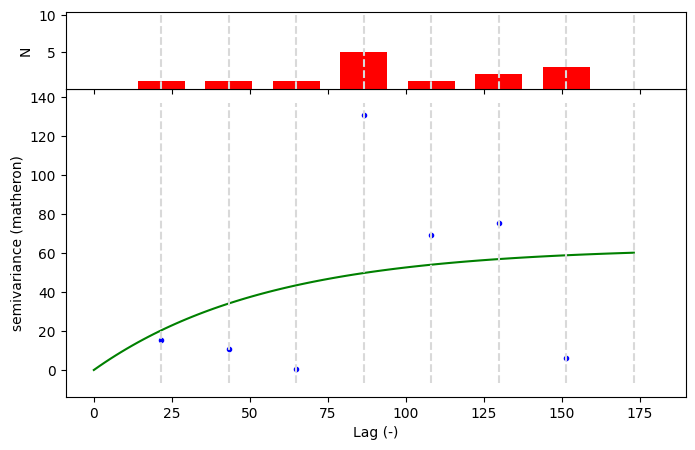

In [24]:
V1 = skg.Variogram(
    lyr1[['easting', 'northing']].values, 
    lyr1['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V1.plot()

In [25]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V1.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 166.11090288613792 meters


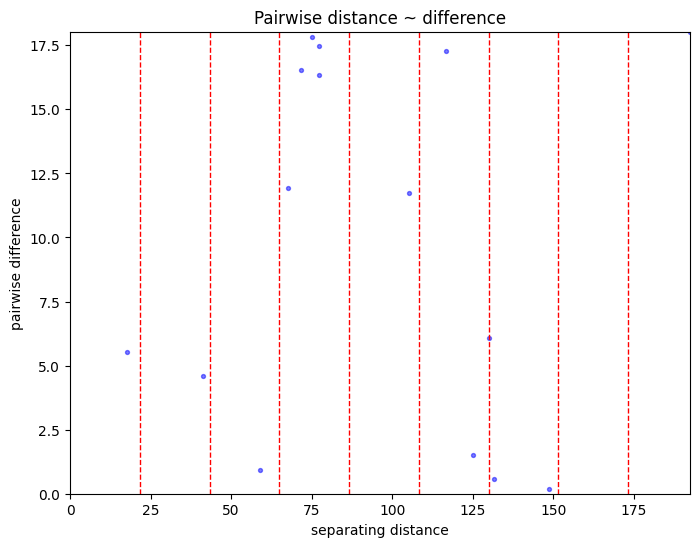

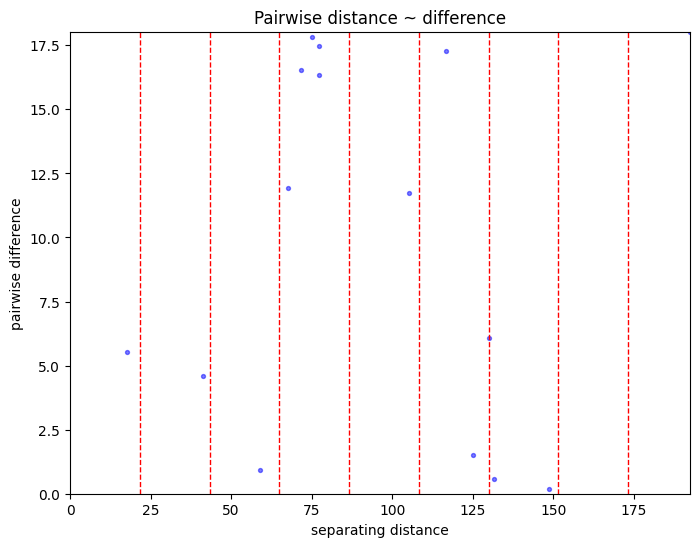

In [26]:
V1.distance_difference_plot(show=False)

In [27]:
ok1 = skg.OrdinaryKriging(V1, min_points=1, mode='exact')
x = lyr1[['easting', 'northing']].values[:, 0]
y = lyr1[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field1 = ok1.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok1.sigma.reshape(xx.shape)

In [28]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field1, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords1 = np.column_stack([df_pp1['x'].values, df_pp1['y'].values])
sampled_values1 = interpolator(sample_coords1)

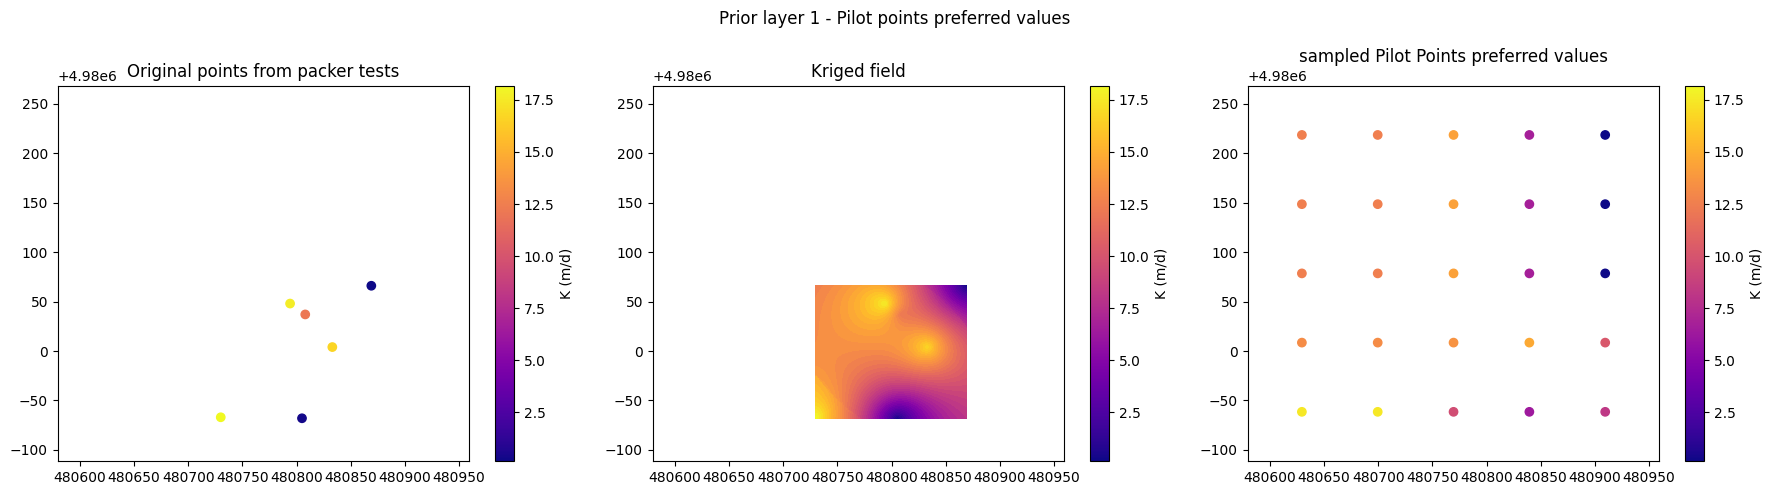

In [29]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr1['Kh (m/day)'].min(), field1.min(), sampled_values1.min())
vmax = max(lyr1['Kh (m/day)'].max(), field1.max(), sampled_values1.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr1['easting'], lyr1['northing'], 
    c=lyr1['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field1.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values1, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 1 - Pilot points preferred values')

plt.tight_layout()
plt.show()

asserting pilot point file was created

In [30]:
pp1_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp1_file)

In [31]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


updating initial value + parameter bounds based on prior data uncertainty

In [32]:
df_pp1['parval1'] = sampled_values1
par_bnd_len = np.std(np.log(lyr1['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp1['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp1['parval1'].values) + (par_bnd_len/2)
df_pp1['parlbnd'] = 10**parlbnd
df_pp1['parubnd'] = 10**parubnd

In [33]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,12.543329,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,12.543329,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.031977,log,3.577192e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,14.245595,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.042864,log,4.795136e+06,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,6.692150,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.007526,log,8.419539e+05,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,0.156380,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000001,log,1.475322e+02,1.0,pilotpoints


In [34]:
len(df_pp1)

25

pilot points locations

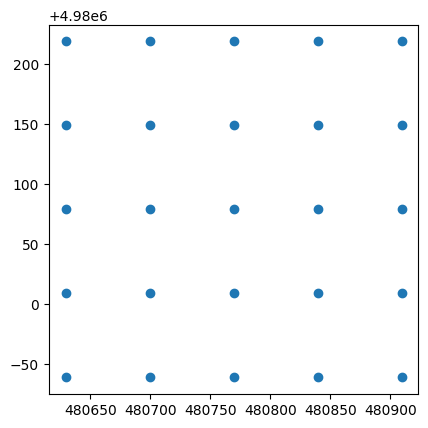

In [35]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [36]:
df_pp2 = pf.add_parameters(
    'k_layer2.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer2", 
    #pargp="pg2", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs_2, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space='C:/Users/lima0055/Documents/MLAC-3D-HT/data/pilot-points-v1.shp', 
    )

2025-11-24 16:38:12.279569 transform was not passed, setting default transform to 'log'
2025-11-24 16:38:12.279569 starting: adding pilotpoints type m style parameters for file(s) ['k_layer2.txt']
2025-11-24 16:38:12.279569 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:50.0,anisotropy:1.0,bearing:0.0

2025-11-24 16:38:12.279569 starting: loading array template\k_layer2.txt
2025-11-24 16:38:12.341596 finished: loading array template\k_layer2.txt took: 0:00:00.062027
2025-11-24 16:38:12.341596 loaded array 'mf6\k_layer2.txt' of shape (388, 388)
2025-11-24 16:38:12.482102 starting: writing array-style template file 'template\k_layer2_inst0_pilotpoints.csv.tpl'
2025-11-24 16:38:12.482102 starting: setting up pilot point parameters
2025-11-24 16:38:12.482102 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-24 16:38:12.482102 'use_pp_zones' not set in pp_opt

In [37]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor


In [38]:
columns_to_export = ['name', 'x', 'y', 'zone', 'parval1'] 
df_pp2_subset = df_pp2[columns_to_export]

df_pp2_subset.to_csv(
    os.path.join(template_ws, 'k_layer2_inst0pp.dat'), 
    sep=' ',          #space delimiter
    index=False,
    header=False
)

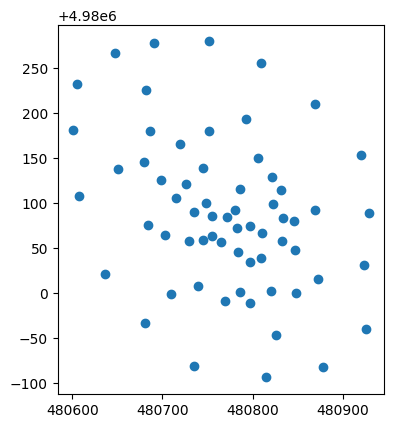

In [39]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp2.x, df_pp2.y)

importing packer + slug test data for layer 2 (BPP)

In [40]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr2 = df_packers[df_packers['layer'] == 2]
lyr2 = lyr2.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
#lyr2 = lyr2.drop(7) #dropping PZ-2, data not reliable
lyr2 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
1,PW-1,4980066,480869,2,8.500000,packer + pumping test,"packer test (PEER, 1999)",NaN,NaN
4,PW-2,4980048,480794,2,24.969600,packer test,"packer test (PEER, 1999)",NaN,NaN
7,PZ-2,4980037,480808,2,19.100000,pumping test,"pumping test (PEER, 1999)",NaN,NaN
10,94-02,4980038,480890,2,7.092215,packer test,"packer test (CNA, 1997)","average between (6.46046, 7.72397)",NaN
13,94-07,4980198,480782,2,26.408272,packer test,"packer test (CNA, 1997)","average between (18.10218, 28.69549, 38.02080, 20.81462)",NaN
16,94-08,4979864,480711,2,30.443695,packer test,"packer test (CNA, 1997)","average between (24.31918, 36.56821)",NaN
19,94-09,4979900,480919,2,23.326910,packer test,"packer test (CNA, 1997)",NaN,NaN
22,94-10,4979932,480805,2,51.195490,packer test,"packer test (CNA, 1997)",NaN,NaN
25,94-11,4980004,480833,2,16.897960,packer test,"packer test (CNA, 1997)",NaN,NaN
28,94-16,4979933,480730,2,12.193260,packer test,"packer test (CNA, 1997)",NaN,NaN


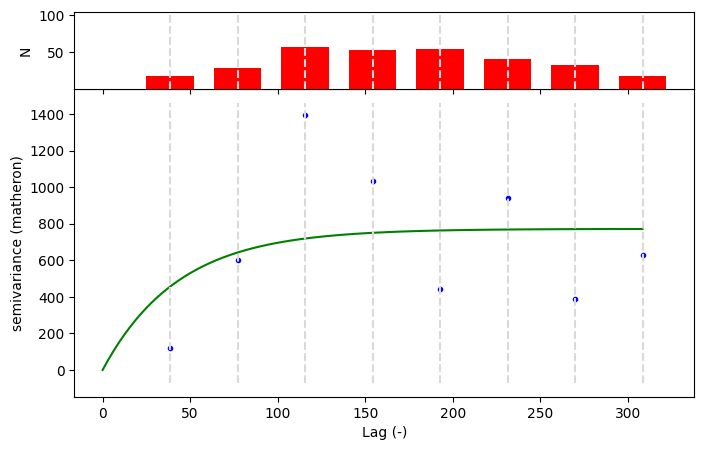

In [41]:
V2 = skg.Variogram(
    lyr2[['easting', 'northing']].values, 
    lyr2['Kh (m/day)'].values.flatten(), 
    maxlag=0.7, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V2.plot()

In [42]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V2.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 129.4944223063351 meters


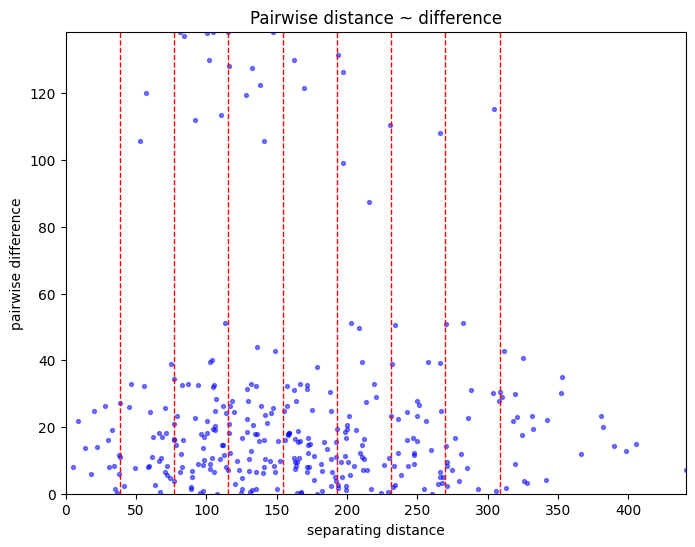

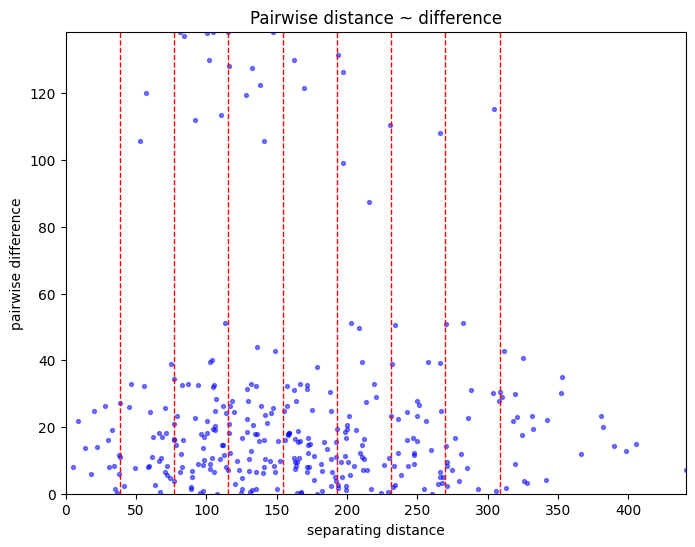

In [43]:
V2.distance_difference_plot(show=False)

In [44]:
ok2 = skg.OrdinaryKriging(V2, min_points=1, mode='exact')
x = lyr2[['easting', 'northing']].values[:, 0]
y = lyr2[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field2 = ok2.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok2.sigma.reshape(xx.shape)

In [45]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field2, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords2 = np.column_stack([df_pp2['x'].values, df_pp2['y'].values])
sampled_values2 = interpolator(sample_coords2)

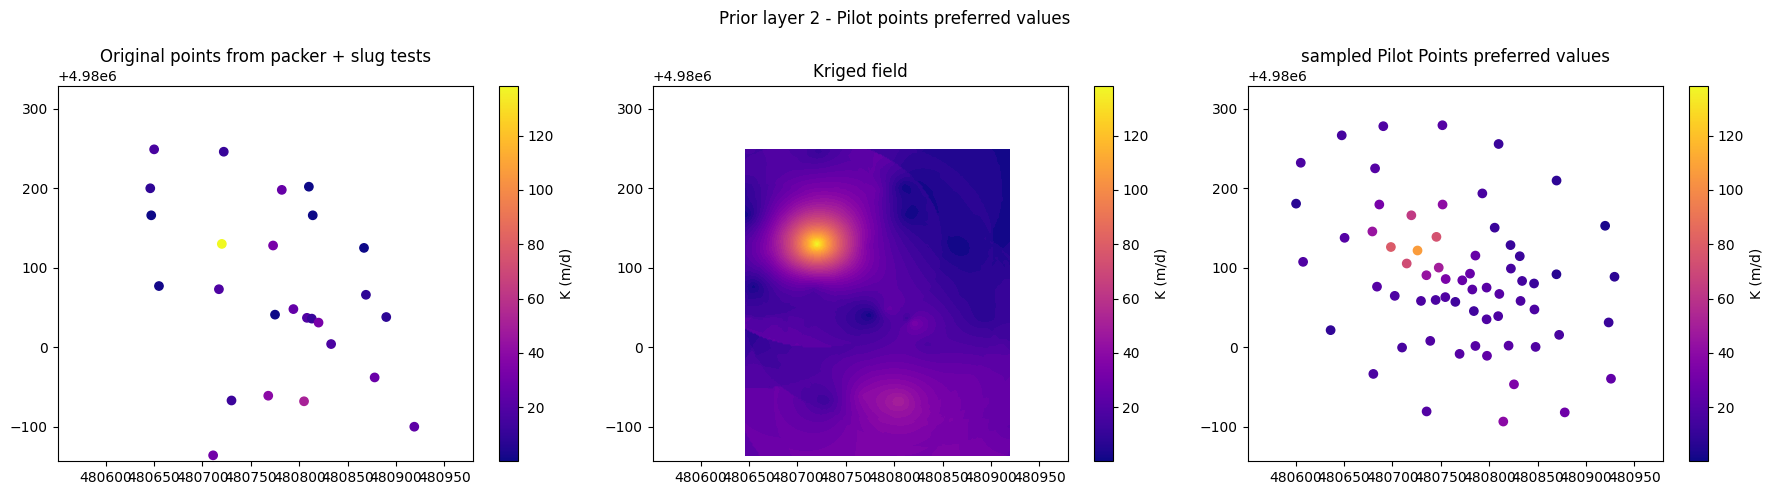

In [46]:
x_min, x_max = df_pp2['x'].min() - 50, df_pp2['x'].max() + 50
y_min, y_max = df_pp2['y'].min() - 50, df_pp2['y'].max() + 50

vmin = min(lyr2['Kh (m/day)'].min(), field2.min(), sampled_values2.min())
vmax = max(lyr2['Kh (m/day)'].max(), field2.max(), sampled_values2.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr2['easting'], lyr2['northing'], 
    c=lyr2['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer + slug tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field2.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp2['x'], df_pp2['y'], 
    #c=df_pp2['parval1'], 
    c=sampled_values2, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 2 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [47]:
pp2_file = os.path.join(template_ws, "k_layer2_inst0pp.dat")
assert os.path.exists(pp2_file)

In [48]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,1,1.0,0.0,factor


In [49]:
df_pp2['parval1'] = sampled_values2
par_bnd_len = np.std(np.log(lyr2['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp2['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp2['parval1'].values) + (par_bnd_len/2)
df_pp2['parlbnd'] = 10**parlbnd
df_pp2['parubnd'] = 10**parubnd
df_pp2['zone'] = 2

In [50]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,dercom,scale,offset,parchglim
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,17.540721,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.338608e+07,0.040031,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,13.825451,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.738191e+06,0.023141,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,21.623789,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,2.167317e+07,0.064814,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,16.912463,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.230776e+07,0.036806,1,1.0,0.0,factor
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,6.484294,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.353665e+06,0.004048,1,1.0,0.0,factor


In [51]:
len(df_pp2)

64

Adding parameter to layer 3: pilot points

In [52]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib3 = gwf.dis.idomain.array[2]
#plt.imshow(ib3)

In [53]:
df_pp3 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70
)

2025-11-24 16:38:35.128082 transform was not passed, setting default transform to 'log'
2025-11-24 16:38:35.128082 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2025-11-24 16:38:35.128082 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0
 took: 0:00:45.602178
2025-11-24 16:38:35.128082 starting: loading array template\k_layer3.txt
2025-11-24 16:38:35.172103 finished: loading array template\k_layer3.txt took: 0:00:00.044021
2025-11-24 16:38:35.172103 loaded array 'mf6\k_layer3.txt' of shape (388, 388)
2025-11-24 16:38:35.312118 starting: writing array-style template file 'template\k_layer3_inst0_pilotpoints.csv.tpl'
2025-11-24 16:38:35.312118 starting: setting up pilot point parameters
2025-11-24 16:38:35.312118 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2025-11-24 16:38:35.312118 'use_pp_zo

In [54]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer test data for layer 3

In [55]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3 = lyr3.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr3 = lyr3.drop(8) #dropping PZ-2, data not reliable
lyr3 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
2,PW-1,4980066,480869,3,0.042080,packer test,"packer test (PEER, 1999)",NaN,NaN
11,94-02,4980038,480890,3,0.209863,packer test,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0.13668)",NaN
14,94-07,4980198,480782,3,0.237867,packer test,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)",NaN
17,94-08,4979864,480711,3,0.288900,packer test,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)",NaN
20,94-09,4979900,480919,3,3.274515,packer test,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0.37062)",NaN
23,94-10,4979932,480805,3,0.149703,packer test,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)",NaN
26,94-11,4980004,480833,3,0.879843,packer test,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)",NaN
29,94-16,4979933,480730,3,0.458860,packer test,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0.10596)",NaN


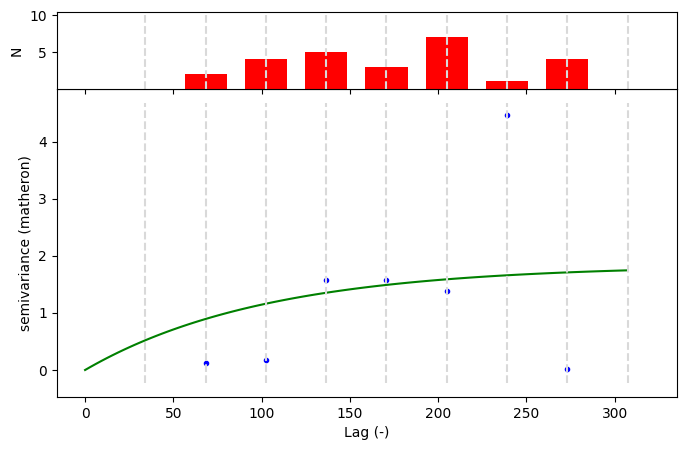

In [56]:
V3 = skg.Variogram(
    lyr3[['easting', 'northing']].values, 
    lyr3['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=9, 
    normalize=False, 
    model='exponential'
    )

fig = V3.plot()

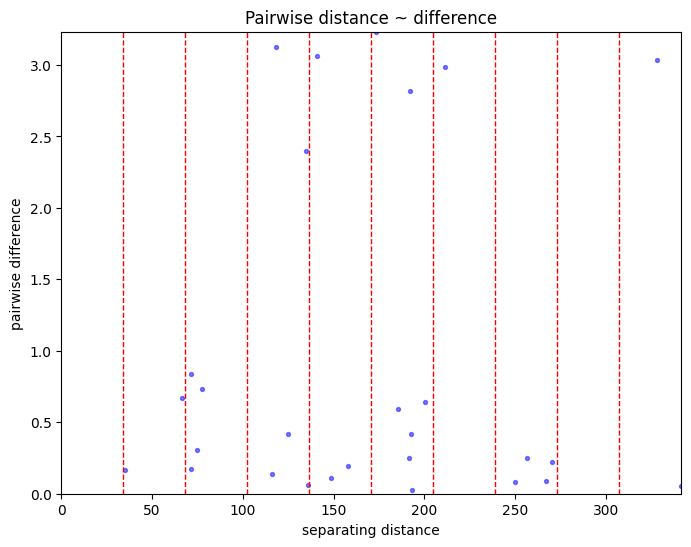

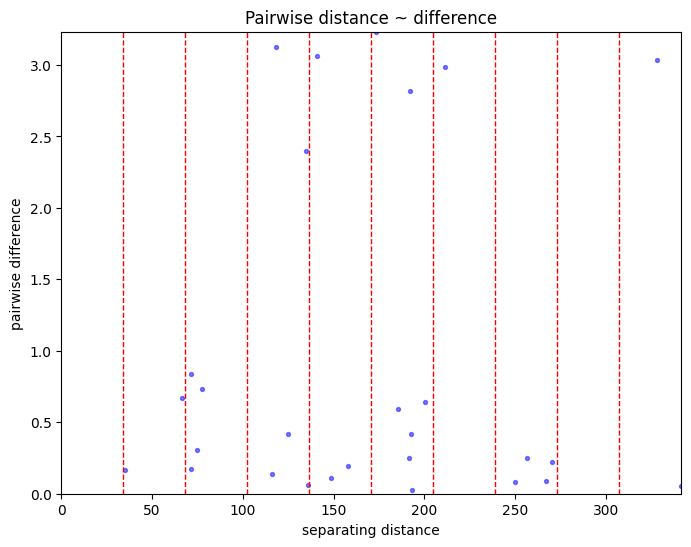

In [57]:
V3.distance_difference_plot(show=False)

In [58]:
print(f"the correlation length for layer 3 based on the packer test data is: {V3.describe()['effective_range']}")

the correlation length for layer 3 based on the packer test data is: 307.31672587088383


In [59]:
ok3 = skg.OrdinaryKriging(V3, min_points=1, mode='exact')
x = lyr3[['easting', 'northing']].values[:, 0]
y = lyr3[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field3 = ok3.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok3.sigma.reshape(xx.shape)

In [60]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field3, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords3 = np.column_stack([df_pp3['x'].values, df_pp3['y'].values])
sampled_values3 = interpolator(sample_coords3)

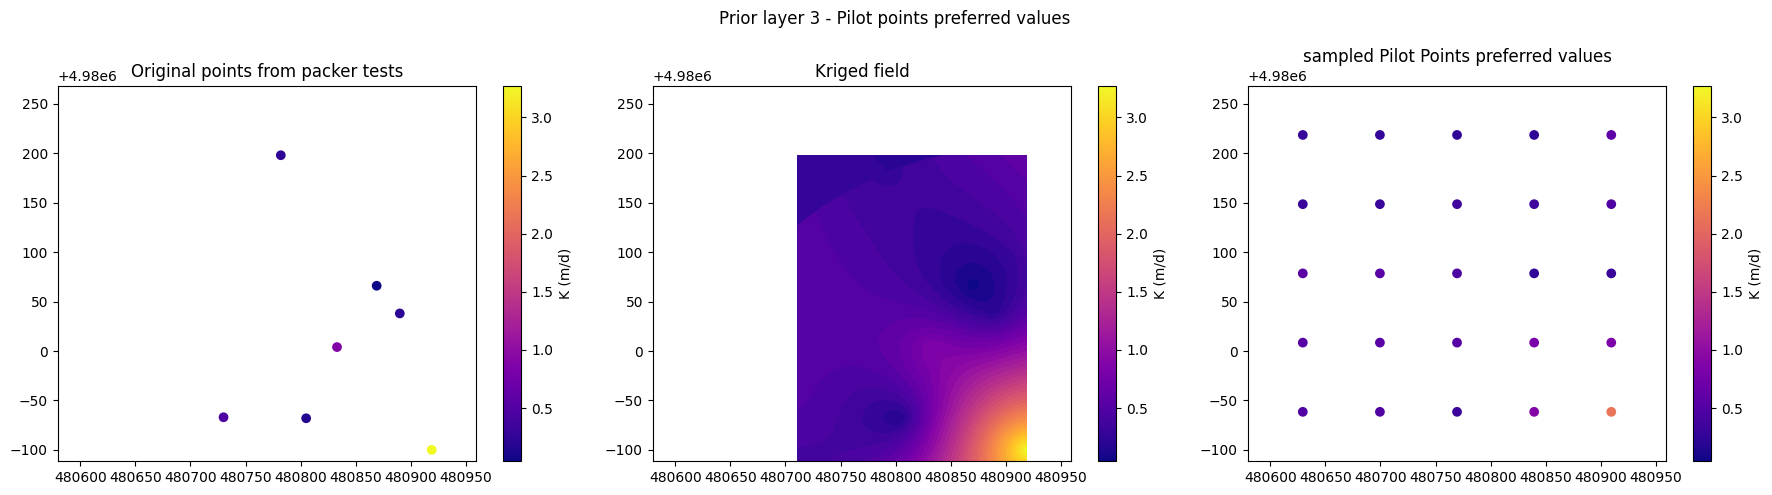

In [61]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr3['Kh (m/day)'].min(), field3.min(), sampled_values3.min())
vmax = max(lyr3['Kh (m/day)'].max(), field3.max(), sampled_values3.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr3['easting'], lyr3['northing'], 
    c=lyr3['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field3.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values3, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 3 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [62]:
pp3_file = os.path.join(template_ws, "k_layer3_inst0pp.dat")
assert os.path.exists(pp3_file)

updating layer index, initial value, and pilot points parameter bounds

In [63]:
df_pp3['k'] = 2
df_pp3['parval1'] = sampled_values3
par_bnd_len = np.std(np.log(lyr3['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp3['parval1'].values) - (par_bnd_len/2)
parubnd = np.log(df_pp3['parval1'].values) + (par_bnd_len/2)
df_pp3['parlbnd'] = 10**parlbnd
df_pp3['parubnd'] = 10**parubnd
df_pp3['zone'] = 3

In [64]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,3,0.281720,2,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,3,0.281720,2,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000215,log,13.619634,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,3,0.248252,2,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000161,log,10.178738,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,3,0.224927,2,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.000128,log,8.110130,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,3,0.589716,2,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,0.001177,log,74.626218,1.0,pilotpoints


Adding mf6 to the command script

In [65]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [66]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst

In [67]:
pst = pf.build_pst()

2025-11-24 16:38:46.441962 starting: Converting parameters to shortnames
2025-11-24 16:38:46.443990 starting: Renaming parameters for shortnames
2025-11-24 16:38:51.096108 finished: Renaming parameters for shortnames took: 0:00:04.652118
2025-11-24 16:38:51.111854 finished: Converting parameters to shortnames took: 0:00:04.669892
2025-11-24 16:38:51.111854 starting: Converting observations to shortnames
2025-11-24 16:38:51.127647 starting: Renaming observations for shortnames
2025-11-24 16:38:55.982714 finished: Renaming observations for shortnames took: 0:00:04.855067
2025-11-24 16:38:56.006379 finished: Converting observations to shortnames took: 0:00:04.894525
noptmax:0, npar_adj:114, nnz_obs:96
2025-11-24 16:38:56.095617 forward_run line:pyemu.os_utils.run(r'mf6')



Changing forward_run.py file to move to each simulation folder and run MODFLOW in there, 

This is, for now, MODFLOW is running sequentially

In [68]:
filename = os.path.join(template_ws, 'forward_run.py')
search_code = "    pyemu.os_utils.run(r'mf6')\n"

paths = [os.path.basename(os.path.normpath(p)) for p in path]

new_code = ''
for i in paths: 
    new_code = new_code + f"    os.chdir('{i}') \n    pyemu.os_utils.run(r'mf6') #running MODFLOW in {i} \n    os.chdir('..')\n"

In [69]:
from helpers import replace_forward_run

replace_forward_run(filename, search_code, new_code)

checking parameter groups and data

In [70]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [71]:
pst.parameter_data.sample(5)

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
p56,p56,log,factor,26.141105,0.100318,3.354573e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480785.73_y:4980115.33_zone:1,p56,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480785.73,4980115.33,1
p86,p86,log,factor,39.214564,0.255223,8.534469e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480814.56_y:4979906.51_zone:1,p86,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480814.56,4979906.51,1
p1,p1,log,factor,12.543329,0.031977,3.577192e+06,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p53,p53,log,factor,71.916797,1.031292,3.448563e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480714.71_y:4980105.35_zone:1,p53,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480714.71,4980105.35,1
p84,p84,log,factor,17.235427,0.038445,1.285569e+07,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480680.20_y:4979966.42_zone:1,p84,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480680.20,4979966.42,1


## checking phimlim for investigation of minimum phi

In [72]:
pst.reg_data.phimlim

'1.0e-10'

minimum phi should be equal to the number of non-zero weighted observations

THIS ASSUMES THAT ALL MODEL-TO-MEASUREMENT MISFIT IS DUE TO MEASUREMENT UNCERTAINTY. In practice model error usually plays a larger role

In [73]:
pst.nnz_obs

96

aasigning PHILIM equal to the number of non-zero weighted observations

In [74]:
#pst.reg_data.phimlim = pst.nnz_obs
pst.reg_data.phimlim

'1.0e-10'

When changing PHIMLIM, we must also change PHIMACCEPT. this is the level of acceptable "measurement objective function".

If PEST achieves PHIMLIM, it will then attempt to minimize the regularization objective function, whiilst maintaining the measurement objective function below PHIMACCEPT

In [75]:
#setting PHIMACCEPT 10% higher than PHIMLIM
pst.reg_data.phimaccept = float(pst.reg_data.phimlim) * 1.1
pst.reg_data.phimaccept

1.1000000000000001e-10

changing PESTMODE to regularization

In [76]:
pst.control_data.pestmode = 'regularization'
pst.control_data.pestmode

'regularization'

updating the maximum number of PEST iteration

In [77]:
pst.control_data.noptmax = 1
pst.control_data.noptmax

np.int32(1)

In [78]:
print(f'there are {pst.nobs} field observation')

there are 96 field observation


changing observation names to meet the PEST version 1 character limit

In [79]:
print('current observation names:')
pst.obs_names[:5]

current observation names:


['ob0', 'ob1', 'ob2', 'ob3', 'ob4']


Each observation group correspond to a well in a injection test. So observation in the same well (and zone) during the same injection test are grouped together

In [80]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,longname,shortname,oglong,oname,otype,time,usecol
ob0,ob0,0.010999,1.0,obg0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,ob0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.010417,head
ob1,ob1,0.022082,1.0,obg0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.020833,head
ob2,ob2,0.037808,1.0,obg0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,ob2,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.041667,head
ob3,ob3,0.049898,1.0,obg0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,ob3,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.0625,head
ob4,ob4,0.006916,1.0,obg1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,ob4,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p,pmw-3,lst,0.010417,head


Checking input and output model files

In [81]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat


In [82]:
pst.model_output_data

,pest_file,model_file
PMW-3_heads.csv.ins,PMW-3_heads.csv.ins,PMW-3_heads.csv
PMW-6_heads.csv.ins,PMW-6_heads.csv.ins,PMW-6_heads.csv


Adding priors

In [83]:
pst.prior_information #no prior info up to now

,pilbl,obgnme,equation,weight


In [84]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


adding preferred-value equations, currently only for layer 1 and 2

In [85]:
#applying preferred value regularization on all parameters
pyemu.helpers.zero_order_tikhonov(
    pst, parbounds=True, #using parameter bounds to specify prior information equation weights
    par_groups=['pg0', 'pg1', 'pg2'], #adding preferred-value only for pp in layer 1 and 3
    ) #setting up preferred-value regularization in the pest control file


In [86]:
pst.prior_information.sample(5)

,pilbl,equation,obgnme,weight
pilbl,,,,
p64,p64,1.0 * log(p64) = 1.276658E+00,regulpg1,0.117312
p103,p103,1.0 * log(p103) = -5.158872E-01,regulpg2,0.208246
p38,p38,1.0 * log(p38) = 1.332019E+00,regulpg1,0.117312
p22,p22,1.0 * log(p22) = 9.800248E-01,regulpg0,0.124244
p83,p83,1.0 * log(p83) = 9.532518E-01,regulpg1,0.117312


In [87]:
#pst.pestpp_options.pop('n_iter_base')
#pst.pestpp_options.pop('n_iter_super')

overwritting pst file

In [88]:
pst.write(os.path.join(template_ws, 'mf6.pst'),version=1)

noptmax:1, npar_adj:114, nnz_obs:96


setting up agents for running PEST in parallel

In [89]:
#number of cores availables
psutil.cpu_count(logical=False)

10

In [90]:
#setting the number of workers
num_workers = 8

In [91]:
#run-manager directory folder (where the manager will be running), 
#outcomes of PEST will be recorded here in a different location than template_ws to avoid mistakes
m_d = 'master_pp'

when running from jupyter notebook slow things down a lot, it is better as the model get complex to run from command lines which is faster and more efficient

Starting workers and running PEST

In [136]:
template_ws

'template'

In [93]:
pyemu.os_utils.start_workers(template_ws, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #manager directory where it will be running
                            verbose=True,
                            )

2025-11-24 17:59:18,409 - MainProcess - INFO - Reserved port 4751 for process 12720


master:pestpp-glm mf6.pst /h :4751 in master_pp
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_0
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_1
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_2
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_3
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_4
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_5
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_6
worker:pestpp-glm mf6.pst /h localhost:4751 in .\worker_7


Running PEST #old

In [74]:
#pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

run():pestpp-glm.exe PMW-6_mf6.pst


plotting results

In [94]:
df_obj = pd.read_csv(os.path.join(m_d, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,obg0,obg1,obg2,obg3,obg4,obg5,obg6,obg7,obg8,obg9,obg10,obg11,obg12,obg13,obg14,obg15,obg16,obg17,obg18,obg19,obg20,obg21,obg22,obg23,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0.942965,0.942965,5.853380e-16,0.000631,0.000648,0.004407,0.018125,0.368570,0.000367,0.008157,0.126942,0.008530,0.013670,0.005794,0.019826,0.000832,0.001214,0.003287,0.014218,0.116884,0.143061,0.000725,0.013723,0.006981,0.024174,0.012025,0.030172,1.951130e-16,1.951130e-16,1.951130e-16
1,130,0.936214,0.936214,4.894730e-08,0.000657,0.000659,0.004583,0.017601,0.366278,0.000393,0.007770,0.125416,0.008788,0.013223,0.005504,0.019243,0.000860,0.001196,0.003356,0.014218,0.116411,0.142468,0.000761,0.013619,0.007042,0.024065,0.012128,0.029976,5.564090e-10,3.437240e-10,4.804720e-08


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

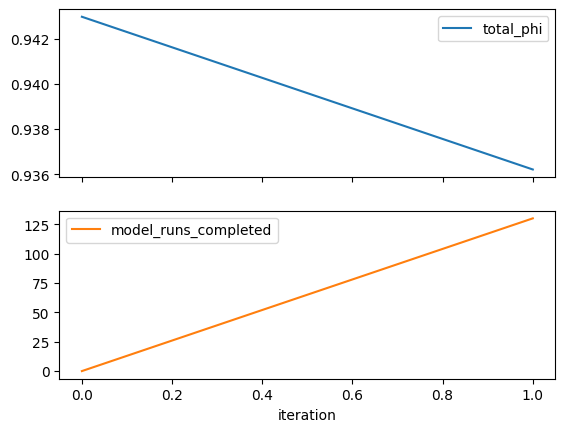

In [95]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

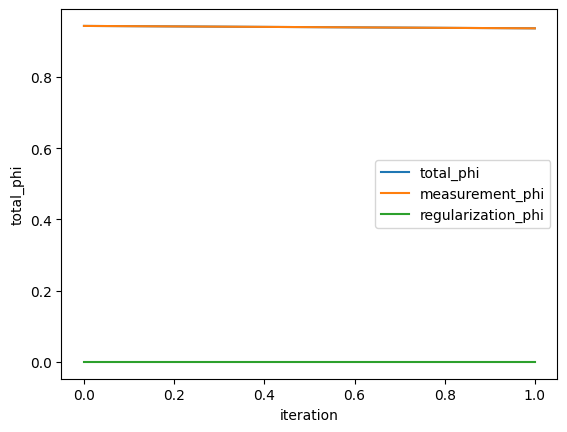

In [96]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');

loading pst

In [97]:
pst = pyemu.Pst(os.path.join(m_d, 'mf6.pst'))

In [98]:
pst.phi

np.float64(0.9362139435651866)

Estimated K values:

In [99]:
pst.parrep(os.path.join(m_d, "mf6.par" ))
pst.write_input_files(pst_path=m_d)
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer1.txt"))

Updating parameter values from master_pp\mf6.par
parrep: updating noptmax to 0


'master_pp\\k_layer1.txt'

Only run for layer 2 when having pilot points

In [100]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer2.txt"))

'master_pp\\k_layer2.txt'

In [101]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer3.txt"))

'master_pp\\k_layer3.txt'

In [102]:
pst.parameter_data.parval1

parnme
p0       12.554868
p1       12.546853
p2       14.229283
p3        6.691985
p4        0.156209
p5       12.550289
p6       12.547698
p7       14.261961
p8        6.703056
p9        0.156376
p10      12.554396
p11      12.549881
p12      14.252070
p13       6.692483
p14       0.156459
p15      13.195407
p16      13.221474
p17      13.596878
p18      14.744846
p19      10.179245
p20      17.422925
p21      17.433431
p22       9.552077
p23       6.337680
p24       8.211388
p25      17.540551
p26      13.809984
p27      21.659433
p28      16.910591
p29       6.486005
p30      15.023340
p31      17.774746
p32      11.508080
p33      20.651245
p34      18.346177
p35      13.736859
p36      17.449265
p37     106.999214
p38      21.474762
p39      15.554756
p40      11.680531
p41      26.658231
p42      18.456855
p43      26.509719
p44      17.326001
p45      18.362217
p46      74.456824
p47      78.873549
p48      33.388677
p49      20.722825
p50      48.814005
p51      62.868844
p52  

In [103]:
import seaborn as sns

<Axes: >

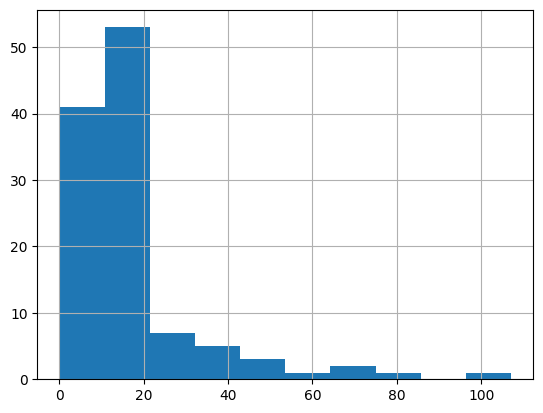

In [104]:
pst.parameter_data.parval1.hist()

In [105]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,12.554868,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,12.546853,0.031977,3.577192e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,14.229283,0.042864,4.795136e+06,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,6.691985,0.007526,8.419539e+05,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,0.156209,0.000001,1.475322e+02,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1


<Axes: xlabel='parval1', ylabel='Count'>

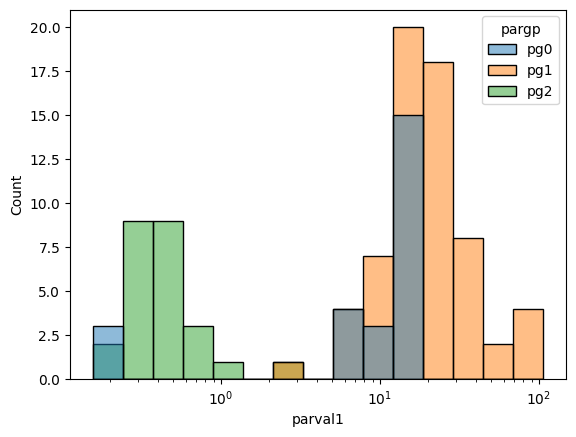

In [106]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [107]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


parnme
p0       3.588131e+12
p1       3.522514e+12
p2       1.695441e+14
p3       4.920221e+06
p4       1.432876e+00
p5       3.550495e+12
p6       3.529375e+12
p7       1.827936e+14
p8       5.047268e+06
p9       1.433428e+00
p10      3.584232e+12
p11      3.547161e+12
p12      1.786774e+14
p13      4.925866e+06
p14      1.433701e+00
p15      1.568221e+13
p16      1.665231e+13
p17      3.952555e+13
p18      5.557066e+14
p19      1.510931e+10
p20      2.648042e+17
p21      2.712885e+17
p22      3.565144e+09
p23      2.176108e+06
p24      1.627000e+08
p25      3.471770e+17
p26      6.456305e+13
p27      4.564916e+21
p28      8.139376e+16
p29      3.061997e+06
p30      1.055214e+15
p31      5.953141e+17
p32      3.221665e+11
p33      4.479662e+20
p34      2.219100e+18
p35      5.455804e+13
p36      2.813618e+17
p37     9.981907e+106
p38      2.983747e+21
p39      3.587202e+15
p40      4.792154e+11
p41      4.552305e+26
p42      2.863222e+18
p43      3.233844e+26
p44      2.118367e+17
p45

plotting head results

In [108]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,obg0,0.010999,0.027921,-0.016921,1.0
ob1,ob1,obg0,0.022082,0.037729,-0.015647,1.0
ob2,ob2,obg0,0.037808,0.048363,-0.010554,1.0
ob3,ob3,obg0,0.049898,0.053661,-0.003762,1.0


<Figure size 800x1050 with 0 Axes>

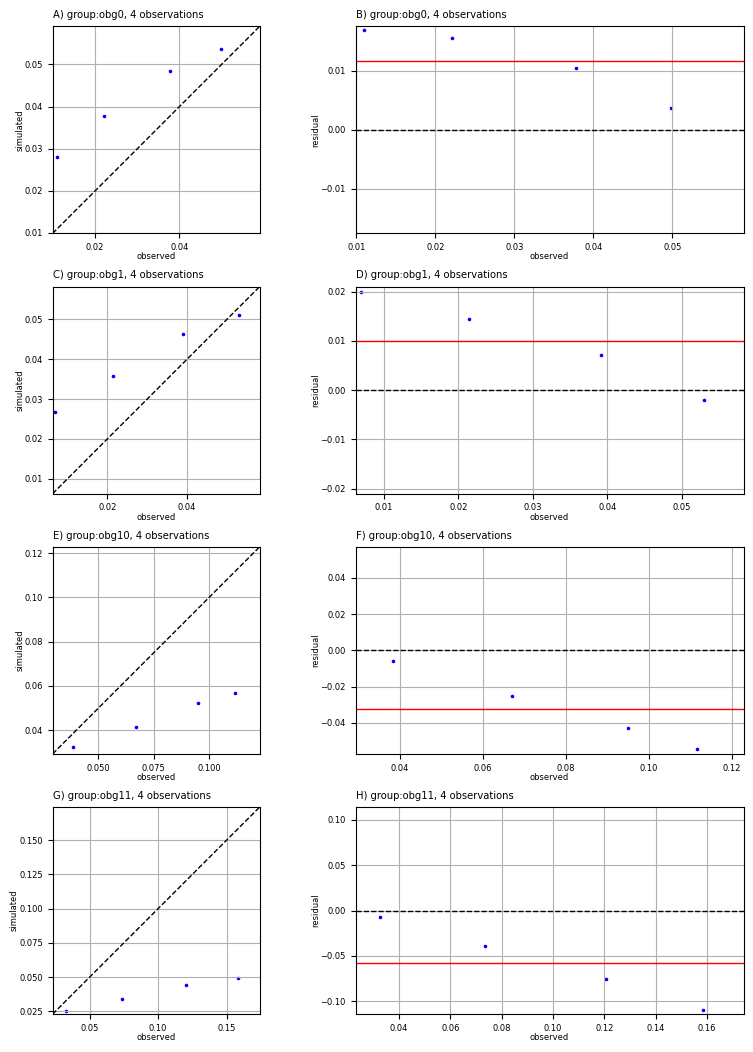

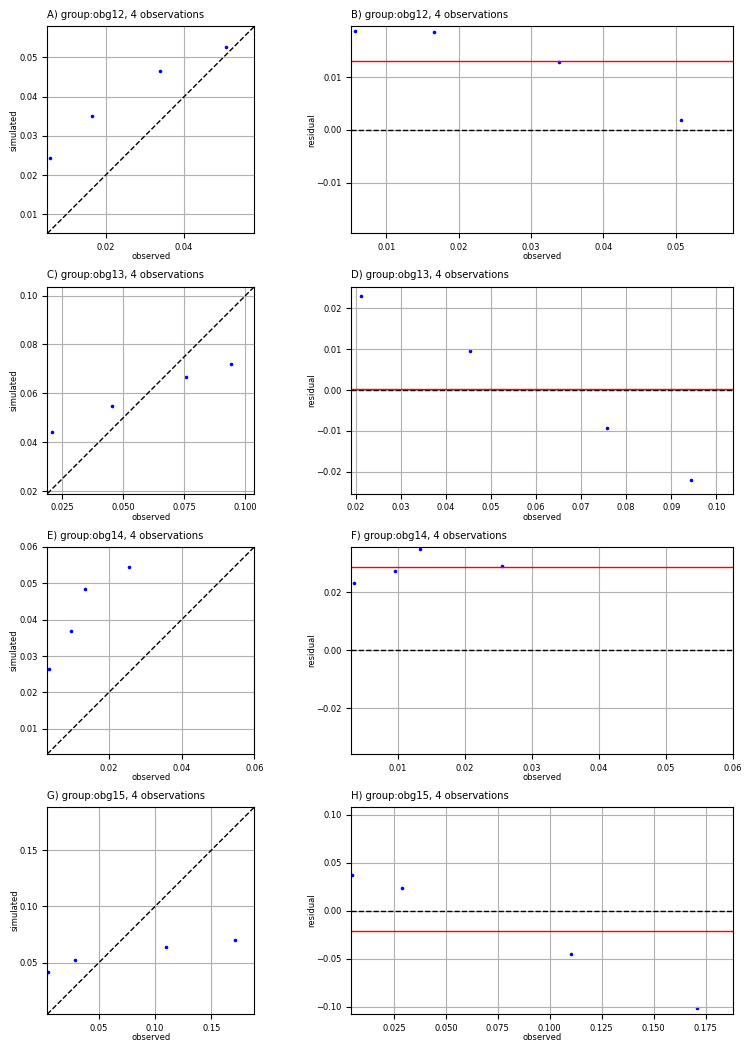

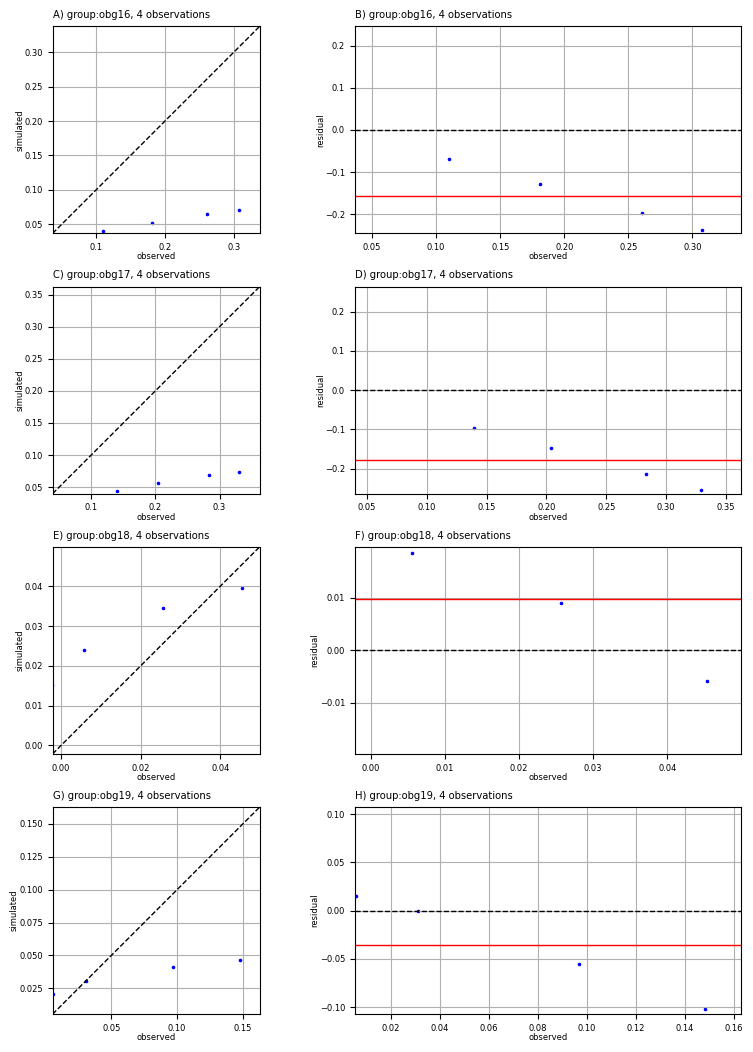

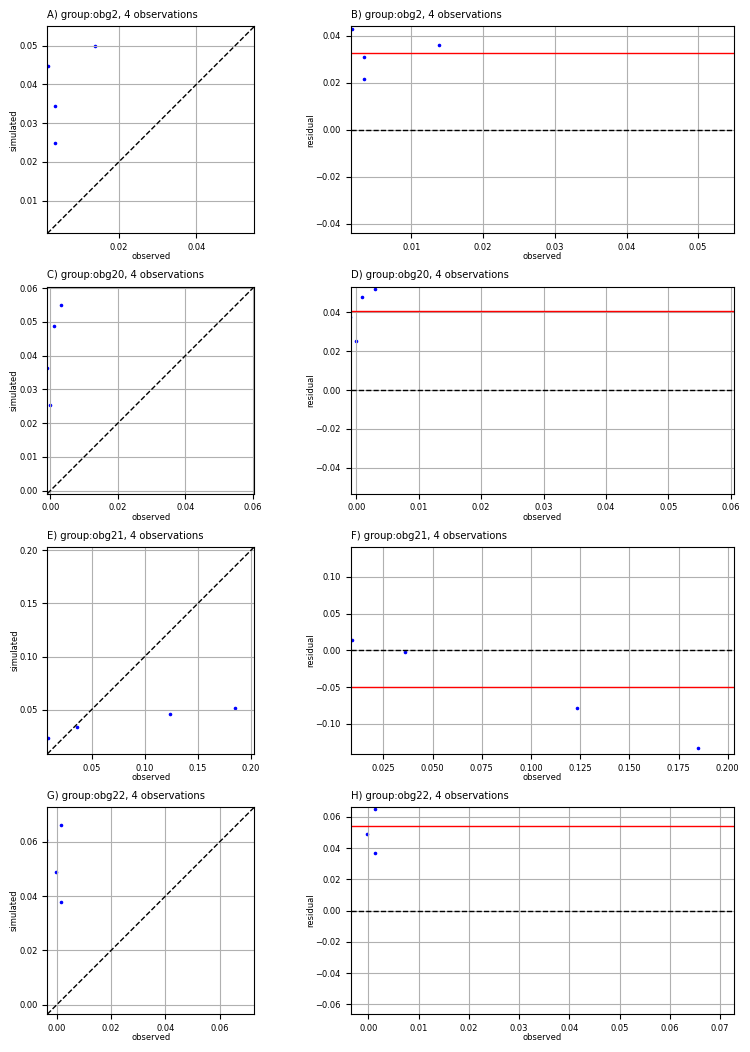

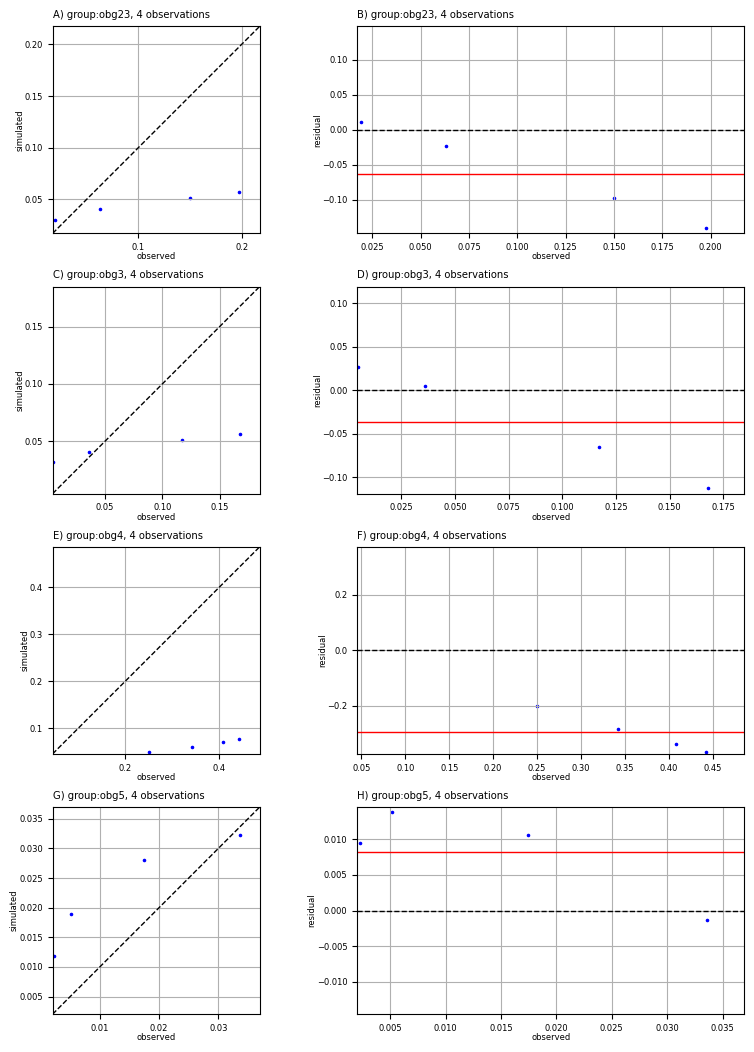

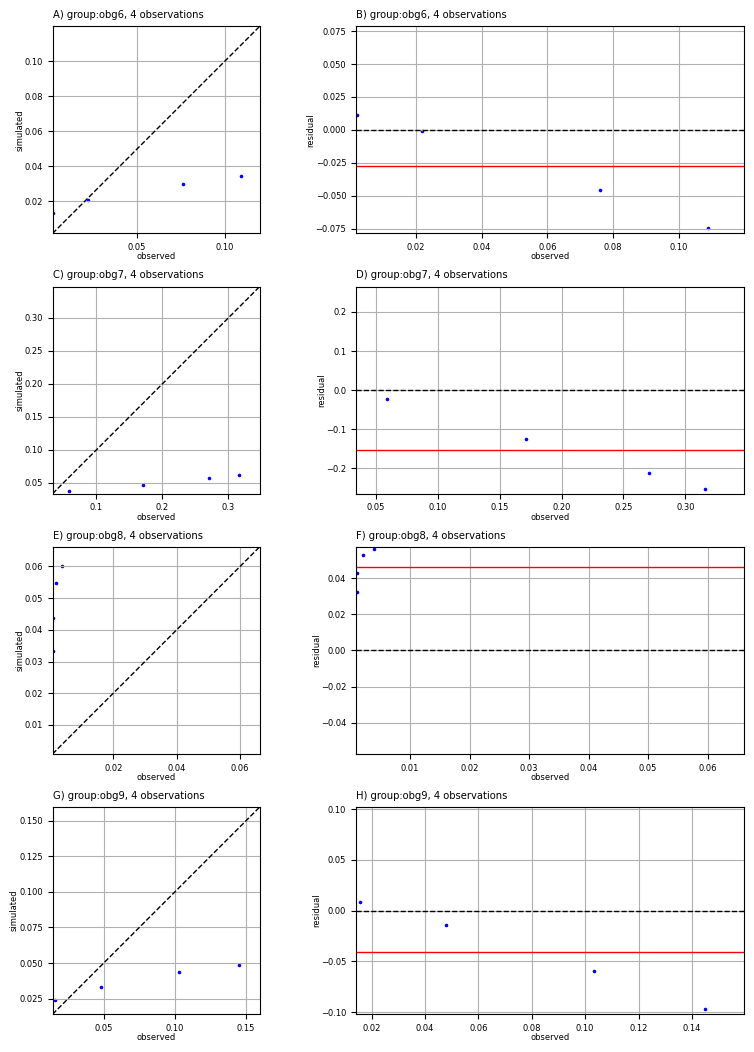

In [109]:
pyemu.plot_utils.res_1to1(pst);

In [110]:
pst.phi

np.float64(0.9362139435651866)

plotting estimated K field

In [112]:
sim_path = os.path.join(m_d, "3d_injection_modeling_PMW-3")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_path)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


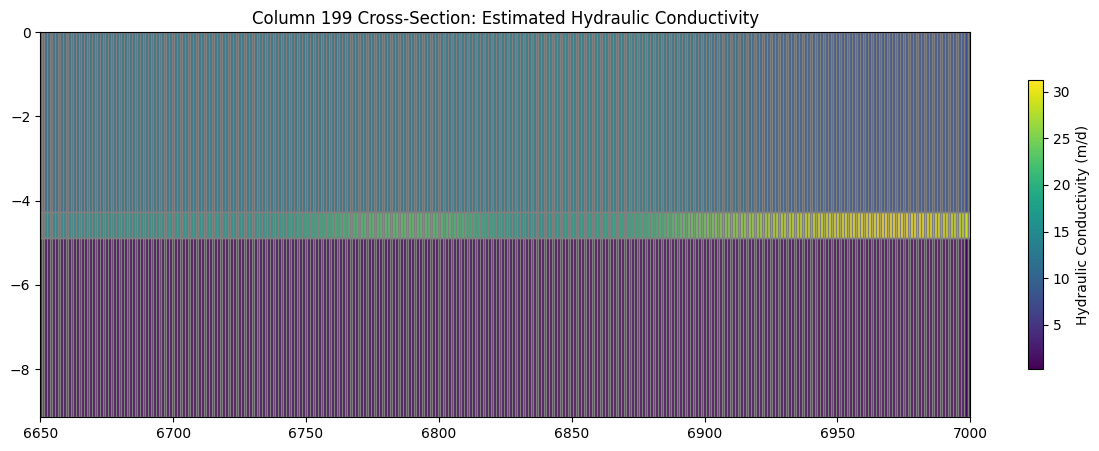

In [113]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

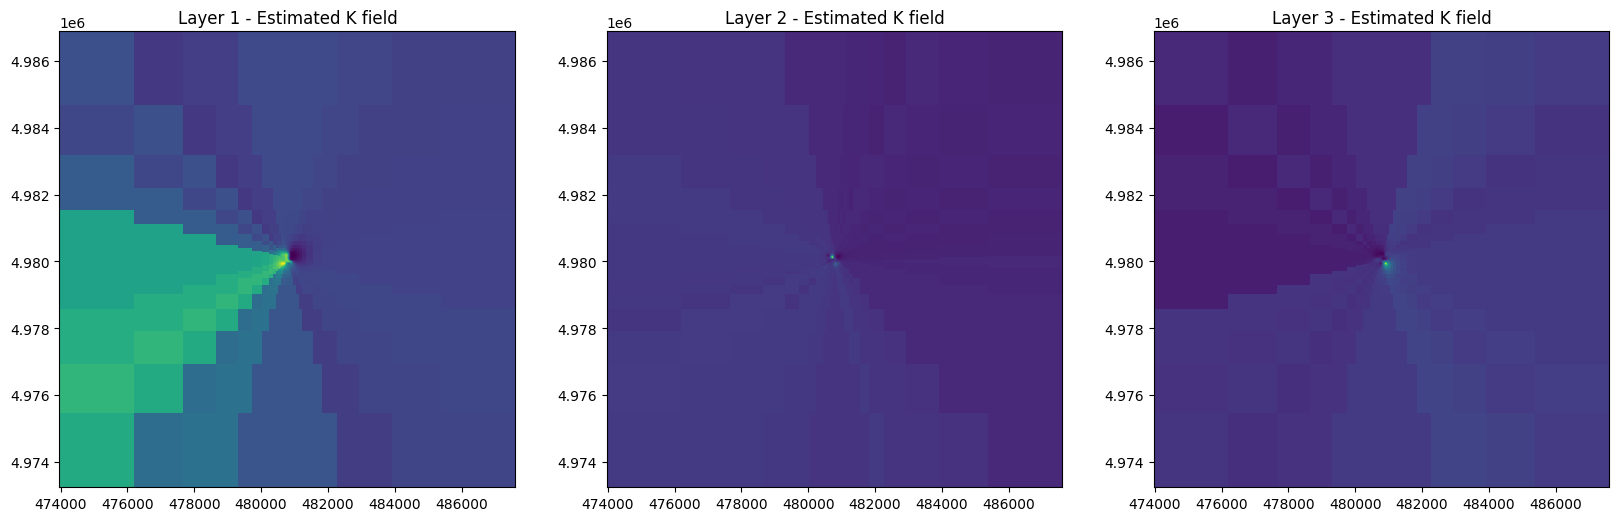

In [114]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

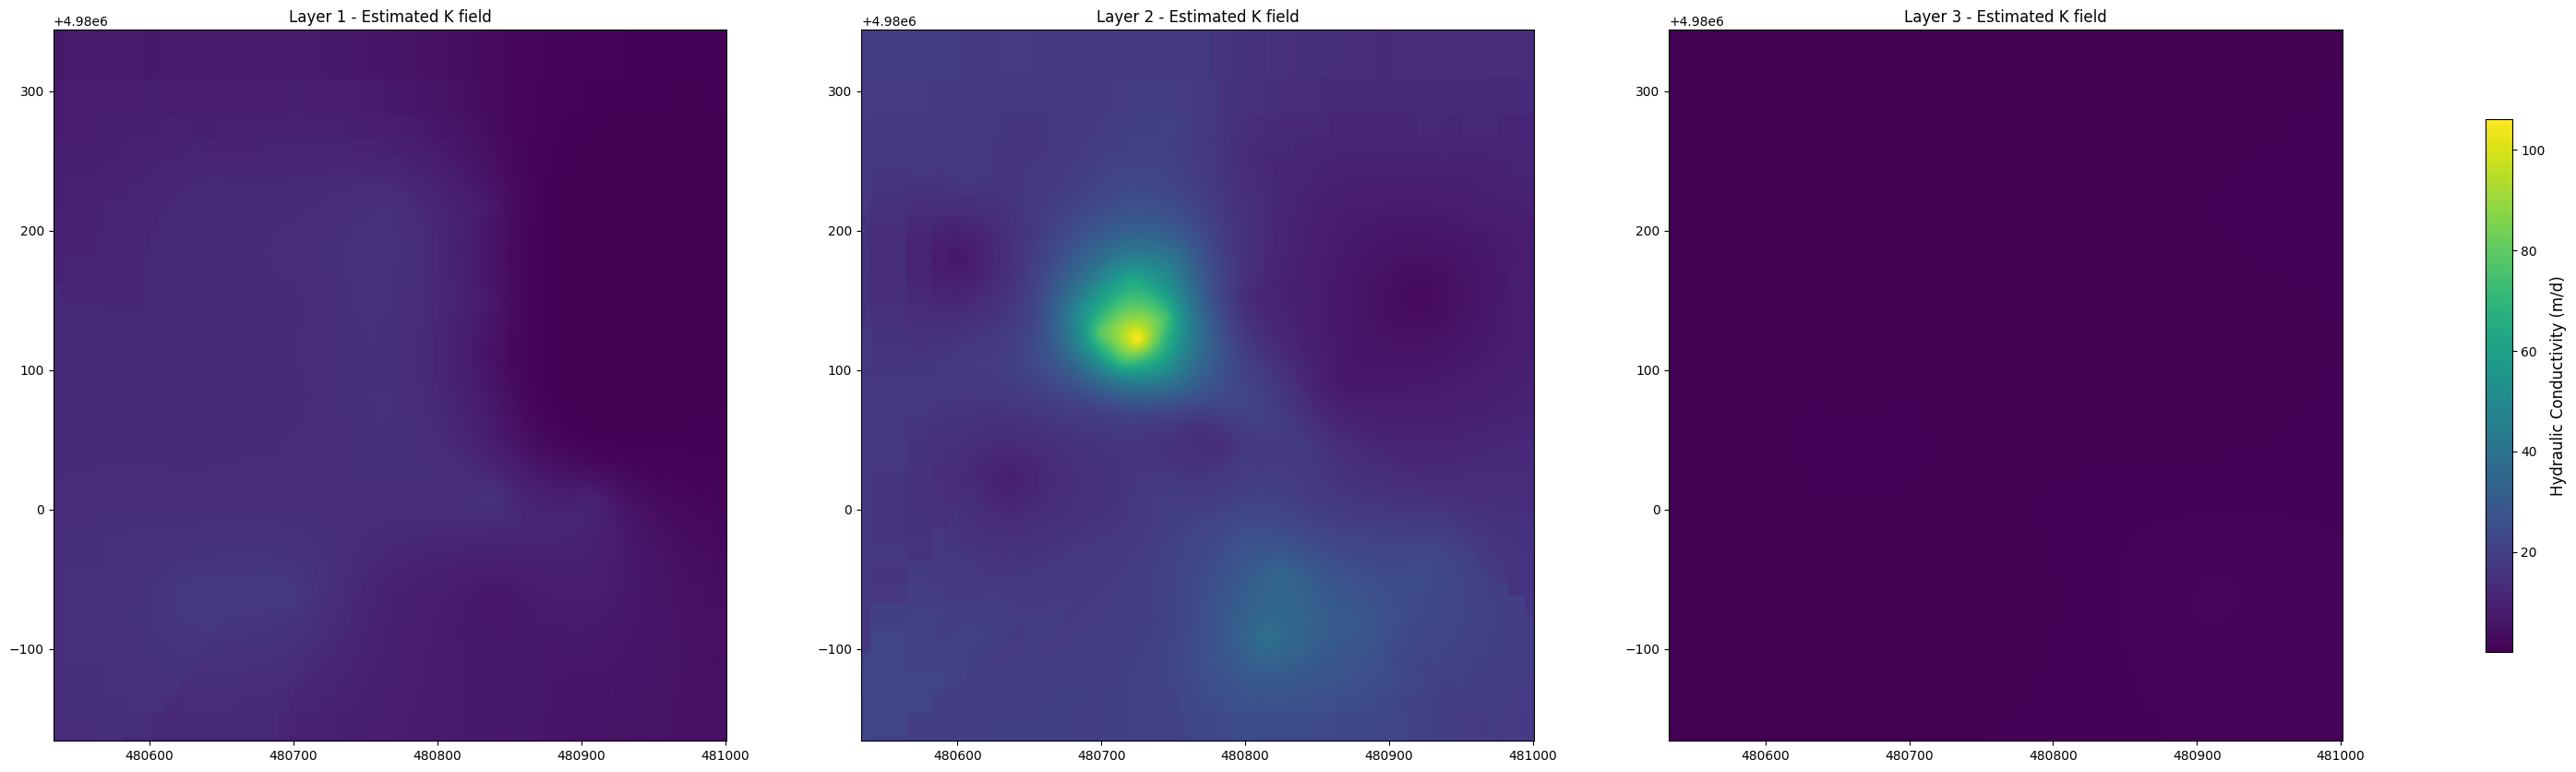

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

In [116]:
from matplotlib.colors import LogNorm 

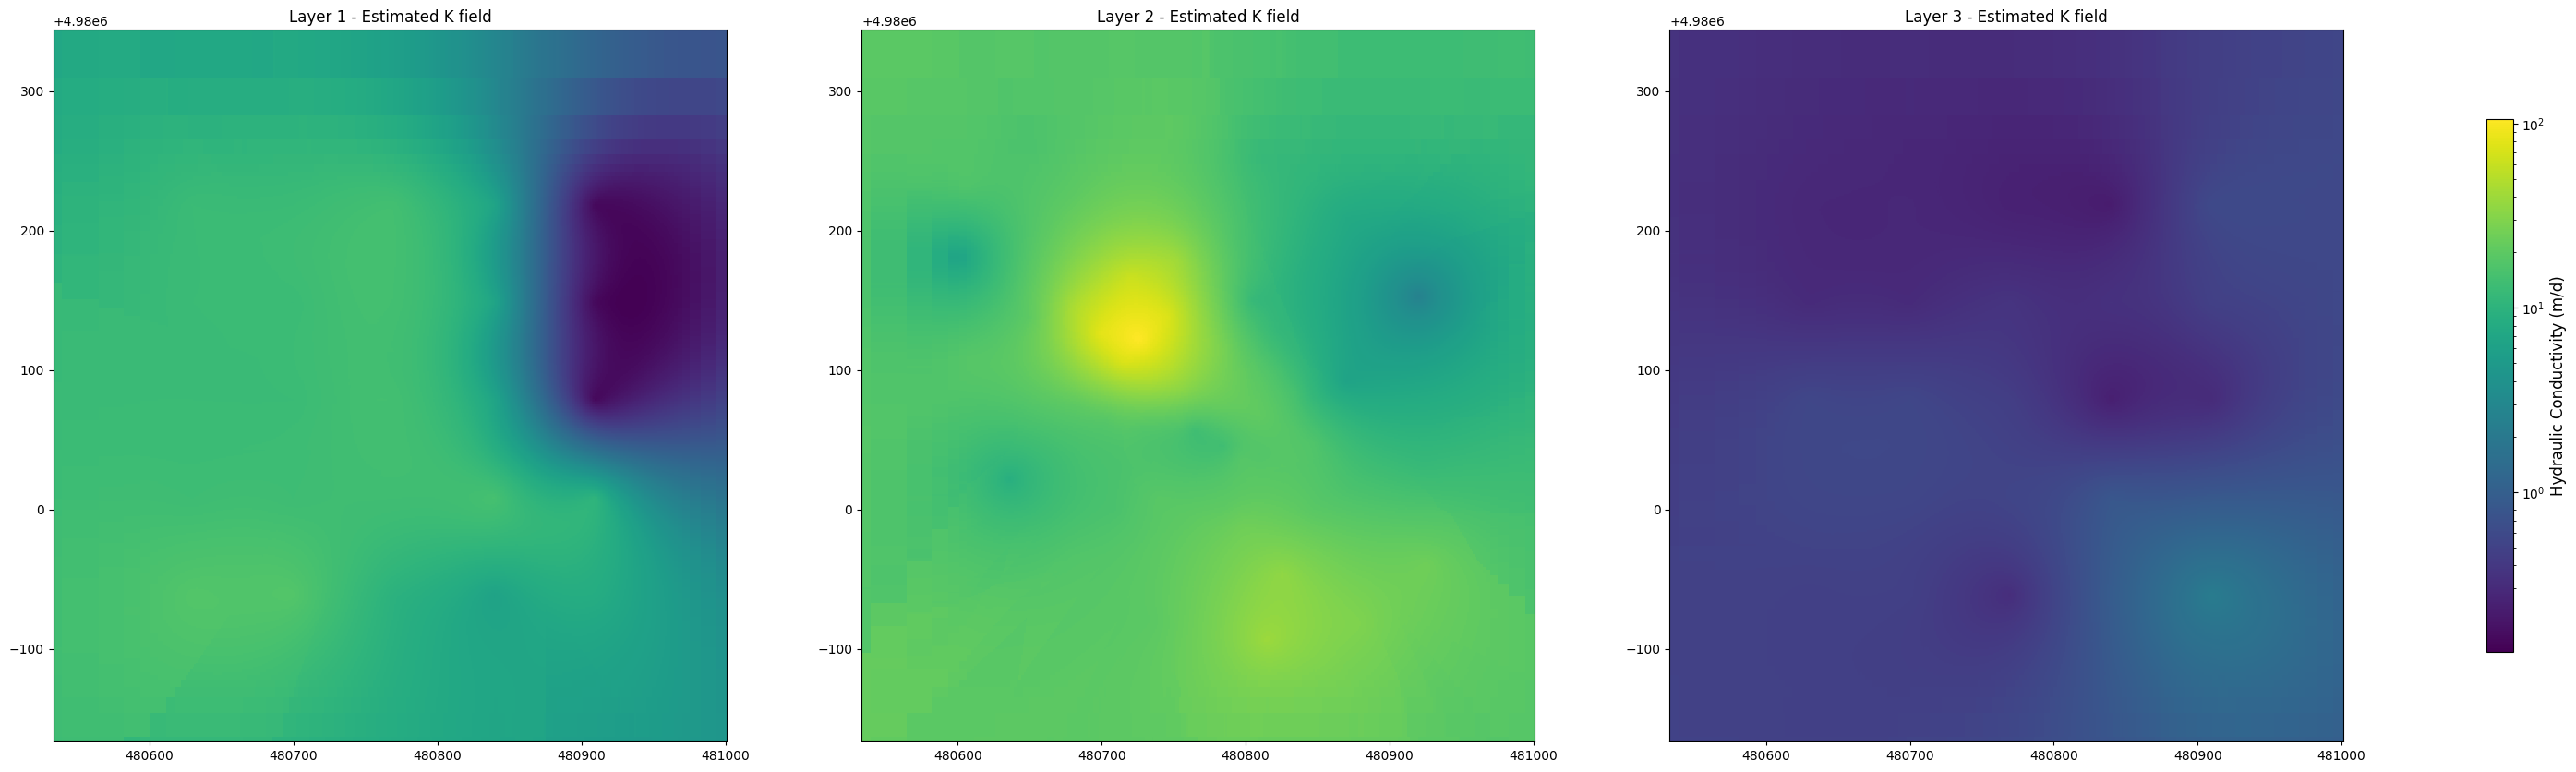

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
vmin = hk_array.min()
vmax = hk_array.max()

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

debugging

In [1]:
import pathlib as pl 
import warnings
import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
